# Online COVID-19 forecasting with a time-varying growth rate

The defining parameter of an unfolding epidemic is its growth rate $g_t$, the weekly
change in log-cases, which serves as a proxy for whether the effective reproduction
number sits above or below 1. It is a textbook *time-varying parameter*: it climbs at
the start of every wave and falls negative as the wave breaks. This example runs
*bayesloop* in online mode, ingesting the weekly case series one point at a time, in
order to forecast next week's cases as data arrive, to show that adapting the growth
rate improves on assuming it is constant, and to raise a real-time flag when a new wave
begins.

A useful property of bayesloop in this setting is that, because the `OnlineStudy` is
forward-only, the model evidence it accumulates is the one-step-ahead predictive
log-likelihood summed over the whole stream. This is a *prequential* score that is
out-of-sample by construction, with no train/test split required (Dawid 1984). The
components we use are `OnlineStudy` (sample-by-sample `step()` streaming), a `Gaussian`
observation model, a `GaussianRandomWalk` transition model compared against a `Static`
one, and real-time probability queries on the filtering posterior.

In [1]:
%matplotlib inline
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import bayesloop as bl

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.edgecolor": "#444444", "grid.color": "#d9d9d9",
})
C = {"data": "#8a8a8a", "accent": "#c1272d", "accent2": "#0b6e99",
     "green": "#2e7d32", "amber": "#e8a33d", "muted": "#8a8a8a",
     "band": "#c1272d", "band2": "#0b6e99"}


def posterior_band(S, name, lo=0.05, hi=0.95):
    """Posterior mean and an equal-tailed credible band for a time-varying parameter."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mean = (p * x[None, :]).sum(axis=1)
    cdf = np.cumsum(p, axis=1)
    low = np.array([np.interp(lo, cdf[t], x) for t in range(p.shape[0])])
    high = np.array([np.interp(hi, cdf[t], x) for t in range(p.shape[0])])
    return mean, low, high


def prob_in(S, name, lo=None, hi=None):
    """Posterior probability the parameter lies in (lo, hi] at each time step."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mask = np.ones_like(x, dtype=bool)
    if lo is not None:
        mask &= x > lo
    if hi is not None:
        mask &= x <= hi
    return p[:, mask].sum(axis=1)

## The data

We use US daily confirmed COVID-19 cases from
[Our World in Data](https://github.com/owid/covid-19-data) (compiled from US CDC / JHU
reporting) and aggregate them to weekly sums to smooth the strong day-of-week reporting
cycle. The raw file holds every country, so we fetch it once, immediately filter to the
United States, and discard the rest. We restrict to the period March 2020 to February
2023, during which reporting was dense and comparable, and model the weekly log-growth
$g_t = \log(\text{cases}_t) - \log(\text{cases}_{t-1})$.

In [2]:
url = ("https://raw.githubusercontent.com/owid/covid-19-data/master/"
       "public/data/cases_deaths/full_data.csv")
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (bayesloop docs)"})
raw = pd.read_csv(io.BytesIO(urllib.request.urlopen(req, timeout=120).read()),
                  usecols=["date", "location", "new_cases"], parse_dates=["date"])
# Filter to the US immediately and drop the rest to keep memory small.
us = raw[raw["location"] == "United States"].sort_values("date").set_index("date")
del raw

wk = us["new_cases"].clip(lower=0).resample("W").sum()
wk = wk[(wk.index >= "2020-03-08") & (wk.index <= "2023-03-01")]
wk = wk.replace(0, np.nan).ffill()
cases = wk.values.astype(float)
dates = wk.index
y = np.log(cases)
g = np.diff(y)                          # weekly log-growth, length N-1
gdates = dates[1:]
N = len(g)
print(f"{N} weekly growth observations, {gdates.min().date()}..{gdates.max().date()}")

155 weekly growth observations, 2020-03-15..2023-02-26


## The observation model

We treat each week's log-growth $g_t$ as Gaussian with a time-varying mean (the growth
rate we want to track) and a free standard deviation that absorbs week-to-week reporting
noise. We wrap it in a small factory so that both studies below receive an identical
fresh copy, which is a prerequisite for their evidences to be directly comparable.

In [3]:
def gauss():
    return bl.om.Gaussian("growth", bl.cint(-1.0, 1.0, 200), "noise", bl.oint(0.02, 0.6, 60))

## The adaptive model

The first `OnlineStudy` gives the growth rate a `GaussianRandomWalk` transition, so that
it is free to drift smoothly from week to week. We stream the 155 weekly observations
through it with `step()`, and at each step we record the filtered growth-rate mean, the
cumulative predictive log-evidence (`S.log_evidence`, in nats), the real-time
probability P(growth > 0) that the epidemic is currently growing, and the full filtered
posterior band. Setting `store_history=True` lets us recover the per-step distributions
afterwards.

In [4]:
Sa = bl.OnlineStudy(store_history=True, silent=True)
Sa.set_observation_model(gauss(), silent=True)
Sa.add_transition_model("adaptive", bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 0.4, 20), target="growth"))
Sa.set_transition_model_prior([1.0], silent=True)
mu_filt, logE_steps = [], []
for val in g:
    Sa.step(val)
    mu_filt.append(Sa.get_current_parameter_mean_value("growth"))
    logE_steps.append(Sa.log_evidence)        # cumulative prequential log-likelihood (nats)
mu_filt = np.array(mu_filt)
p_growing = prob_in(Sa, "growth", lo=0.0)     # real-time P(epidemic growing)
mu_mean, mu_lo, mu_hi = posterior_band(Sa, "growth")
logE_adaptive = float(Sa.log_evidence)

+ Added transition model: adaptive (20 combination(s) of the following hyper-parameters: ['sigma'])
+ Start model fit
    + Set prior (function): jeffreys. Values have been re-normalized.


## The static baseline

The second `OnlineStudy` is identical except that its transition model is `Static()`, so
the growth rate is forced to be one fixed constant for the whole pandemic. Both models
see exactly the same data in the same order, so the difference in their accumulated
predictive log-likelihood is a like-for-like forecasting comparison.

In [5]:
Ss = bl.OnlineStudy(store_history=True, silent=True)
Ss.set_observation_model(gauss(), silent=True)
Ss.add_transition_model("static", bl.tm.Static())
Ss.set_transition_model_prior([1.0], silent=True)
logE_steps_static = []
for val in g:
    Ss.step(val)
    logE_steps_static.append(Ss.log_evidence)
logE_static = float(Ss.log_evidence)

+ Added transition model: static (no hyper-parameters)
+ Start model fit
    + Set prior (function): jeffreys. Values have been re-normalized.


## One-step-ahead point forecasts

Alongside the probabilistic score we also build causal point forecasts of next week's
growth. The adaptive forecast uses the current filtered mean, $\hat g_{t+1} = \mu_t$; we
compare it to a naive persistence rule ($\hat g_{t+1} = g_t$) and an expanding-mean
static forecast. From the adaptive growth forecast we also obtain a one-step case-count
forecast, $\text{cases}_{t+1} = \text{cases}_t \cdot \exp(\mu_t)$, and score it with
MAPE.

In [6]:
pred_adaptive = mu_filt[:-1]
pred_persist = g[:-1]
exp_mean = np.array([g[:i + 1].mean() for i in range(N - 1)])
actual = g[1:]
def rmse(p): return float(np.sqrt(np.mean((actual - p) ** 2)))
# case-count one-step forecast from adaptive growth
cases_pred = cases[1:-1] * np.exp(mu_filt[:-1])     # predict cases[t+1]
cases_actual = cases[2:]
mape_cases_adaptive = float(np.mean(np.abs(cases_pred - cases_actual) / cases_actual))

## Real-time wave detection

Finally we turn the posterior into an alarm: every week where the real-time P(growing)
crosses 0.5 from below marks the onset of a new wave. Because the OnlineStudy only ever
uses data up to the current week, these crossings are exactly what a live now-casting
dashboard would have flagged in real time.

In [7]:
cross_up = [(gdates[i].date().isoformat())
            for i in range(1, N) if p_growing[i] > 0.5 and p_growing[i - 1] <= 0.5]

print(f"Prequential predictive log-likelihood (log10): adaptive {logE_adaptive/np.log(10):.1f}, "
      f"static {logE_static/np.log(10):.1f}  => gain {(logE_adaptive-logE_static)/np.log(10):.1f}")
print(f"One-step growth RMSE: adaptive {rmse(pred_adaptive):.3f}, persistence {rmse(pred_persist):.3f}, "
      f"static-mean {rmse(exp_mean):.3f}")
print(f"Adaptive one-step case MAPE: {100*mape_cases_adaptive:.0f}%")
print(f"Detected wave onsets (P(growing) up-crossings): {cross_up}")

Prequential predictive log-likelihood (log10): adaptive -10.9, static -26.3  => gain 15.4
One-step growth RMSE: adaptive 0.241, persistence 0.235, static-mean 0.359
Adaptive one-step case MAPE: 17%
Detected wave onsets (P(growing) up-crossings): ['2020-06-14', '2020-09-27', '2021-04-04', '2021-07-11', '2021-11-21', '2021-12-05', '2022-04-17', '2022-06-26', '2022-11-13', '2022-11-27', '2023-01-08']


The up-crossings line up with the actual US wave timeline (summer 2020, winter 2020,
Delta, Omicron, BA.2, BA.5, and the winter 2022/23 waves), each flagged as it began.

## The forecast, the growth rate, and the wave indicator

The three panels below summarise the analysis: the one-week-ahead case forecast tracking
the actual series (with the unavoidable one-week causal lag), the inferred growth rate
rising above zero at each wave onset and falling negative as each wave breaks, and the
real-time P(growing) alarm.

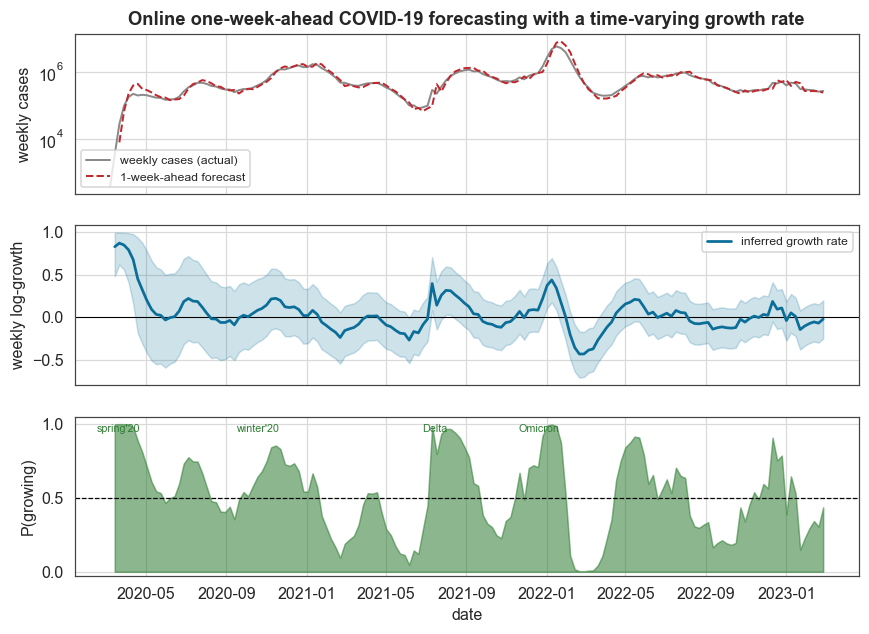

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9.2, 6.4), sharex=True)
ax1.semilogy(dates, cases, color=C["data"], lw=1.3, label="weekly cases (actual)")
ax1.semilogy(dates[2:], cases_pred, color=C["accent"], lw=1.3, ls="--", label="1-week-ahead forecast")
ax1.set_ylabel("weekly cases")
ax1.set_title("Online one-week-ahead COVID-19 forecasting with a time-varying growth rate")
ax1.legend(loc="lower left", fontsize=8)

ax2.axhline(0, color="k", lw=0.7)
ax2.plot(gdates, mu_mean, color=C["accent2"], lw=1.8, label="inferred growth rate")
ax2.fill_between(gdates, mu_lo, mu_hi, color=C["band2"], alpha=0.2)
ax2.set_ylabel("weekly log-growth")
ax2.legend(loc="upper right", fontsize=8)

ax3.fill_between(gdates, 0, p_growing, color=C["green"], alpha=0.55)
ax3.axhline(0.5, color="k", ls="--", lw=0.8)
ax3.set_ylabel("P(growing)")
ax3.set_xlabel("date")
ax3.set_ylim(-0.03, 1.05)
for lab, d in [("spring'20", "2020-03-20"), ("winter'20", "2020-10-20"),
               ("Delta", "2021-07-15"), ("Omicron", "2021-12-20")]:
    dd = pd.Timestamp(d)
    if gdates.min() <= dd <= gdates.max():
        ax3.text(dd, 1.0, lab, fontsize=7, rotation=0, ha="center", va="top", color=C["green"])
plt.show()

## Probabilistic prediction

Summed over all one-step-ahead forecasts, the adaptive model's predictive log-likelihood
exceeds the static model's by roughly +15 log₁₀; the data stream is about a quadrillion
times more probable under the model that lets the growth rate evolve. The cumulative
curve (left) shows the adaptive model ahead at every step, not just on average.

The point-error bar chart (right) shows a more nuanced picture. On raw one-step growth
error the adaptive forecast clearly improves on the static-mean forecast but only ties a
naive persistence rule. This is expected: when a parameter behaves like a random walk,
"tomorrow ≈ today" is a strong point predictor. The value bayesloop adds here is not a
lower point error but a calibrated predictive distribution (hence the
15-order-of-magnitude likelihood gain) together with a denoised, interpretable
growth-rate estimate with uncertainty, which a persistence rule cannot provide.

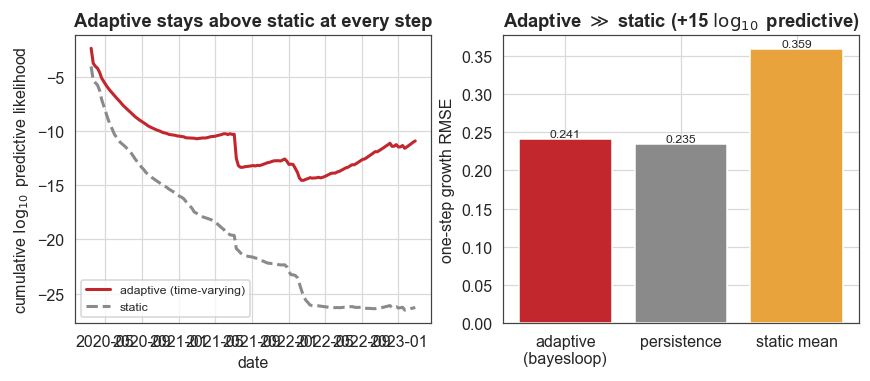

In [9]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(9.2, 3.4))
axa.plot(gdates, np.array(logE_steps) / np.log(10), color=C["accent"], lw=2, label="adaptive (time-varying)")
axa.plot(gdates, np.array(logE_steps_static) / np.log(10), color=C["muted"], lw=2, ls="--", label="static")
axa.set_ylabel(r"cumulative $\log_{10}$ predictive likelihood")
axa.set_xlabel("date")
axa.set_title("Adaptive stays above static at every step")
axa.legend(fontsize=8, loc="lower left")
labels = ["adaptive\n(bayesloop)", "persistence", "static mean"]
vals = [rmse(pred_adaptive), rmse(pred_persist), rmse(exp_mean)]
axb.bar(labels, vals, color=[C["accent"], C["muted"], C["amber"]])
axb.set_ylabel("one-step growth RMSE")
axb.set_title(r"Adaptive $\gg$ static (+%d $\log_{10}$ predictive)" % round((logE_adaptive - logE_static) / np.log(10)))
for i, v in enumerate(vals):
    axb.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
plt.show()

## What this example showed

A one-parameter online model, the time-varying epidemic growth rate, gave us credible
one-week-ahead COVID-19 forecasts, clearly outperformed a static model in proper
probabilistic scoring, and detected the onset of every major US wave in real time. In
doing so we used bayesloop to:

- stream data one point at a time with `OnlineStudy.step()`, taking each decision from
  the current filtering posterior exactly as a live now-casting dashboard would;
- score forecasts probabilistically, where the accumulated online evidence is the
  prequential one-step-ahead predictive log-likelihood, out-of-sample by construction
  with no train/test split;
- compare parameter dynamics like-for-like, using an identical Gaussian observation
  model under `GaussianRandomWalk` versus `Static`, where letting the growth rate drift
  wins by about 15 orders of magnitude in predictive likelihood;
- turn the posterior into an alarm, where P(growth > 0) crossing 0.5 flags every wave as
  it begins, with a history that matches the US pandemic record;
- distinguish the two kinds of accuracy, since the gain is in probabilistic prediction
  and uncertainty calibration rather than in point error versus a persistence rule.